# Invasive Ductal Carcinoma (IDC) Classification CNN
### Binary Classification of Breast Tissue Patches, 50×50px Histopathology Images

**Dataset:** 277,524 patches (198,738 IDC-negative, 78,786 IDC-positive)  
**Task:** Binary classification - IDC Positive (1) vs IDC Negative (0)

---
For ease of navigation through notebook
## Table of Contents
1. [Environment Setup & Imports](#1)
2. [Dataset Discovery & EDA](#2)
3. [Dataset Splitting Strategy](#3)
4. [Data Pipeline](#4)
5. [Preprocessing & Augmentation](#5)
6. [Model Architecture](#6)
7. [Training Strategy & Callbacks](#7)
8. [Model Evaluation](#8)
9. [Visualisation & Explainability](#9)
10. [Saving & Export](#10)

## 1. Environment Setup & Imports <a id='1'></a>

**Note:** I recommend running this notebook on a machine with a CUDA-capable GPU. Training on CPU will be incredibly slower. Mixed-precision (`float16`) is enabled below to halve VRAM usage and speed up GPU matrix ops.

In [1]:
import os, random, warnings, pathlib, logging, json, time
from collections import Counter

#These are optional and down to preference
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'        # Suppresses all TF C++ logging
os.environ['CUDA_VISIBLE_DEVICES'] = '0'         # Explicitly select GPU 0
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'        # Suppresses the oneDNN warning too
logging.getLogger('tensorflow').setLevel(logging.ERROR)  # Python-level TF logs

# Numbers and Visualisation
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_curve, auc, precision_recall_curve,
                             average_precision_score)

os.environ['KERAS_BACKEND'] = 'tensorflow'
# Deep Learning imports
import keras
from keras import layers, regularizers, mixed_precision
from keras.callbacks import (EarlyStopping, ReduceLROnPlateau,
                             ModelCheckpoint, CSVLogger)
import tensorflow as tf
print(keras.__version__, keras.backend.backend())

# For reproducibility
SEED = 42
keras.utils.set_random_seed(SEED)

# Mixed precision (float16 on GPU, float32 on CPU)
# Note: Mixed precision cuts GPU memory in half and speeds up
# matmul/conv ops on Tensor Cores (Volta+). Safe for classification tasks.
# Only beneficial in a meaningful way if GPU device has Tensor Cores.
policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)
print(f'Compute dtype  : {policy.compute_dtype}')
print(f'Variable dtype : {policy.variable_dtype}')

# GPU verification
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for g in gpus:
        tf.config.experimental.set_memory_growth(g, True)  # Avoid OOM allocations
    print(f'\n{len(gpus)} GPU(s) detected: {[g.name for g in gpus]}')
else:
    print('\nNo GPU detected — training will use CPU (expect longer runtimes).')

print(f'\nTensorFlow version: {tf.__version__}')

# For visualisations
def load_patch(path):
    img = plt.imread(path).astype(np.float32)
    return img / 255.0 if img.max() > 1.0 else img

3.12.2 tensorflow
Compute dtype  : float16
Variable dtype : float32

1 GPU(s) detected: ['/physical_device:GPU:0']

TensorFlow version: 2.17.0


I0000 00:00:1791153937.522861    1591 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1791153938.340916    1591 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1791153938.340987    1591 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.


## 2. Dataset Discovery & Exploratory Data Analysis <a id='2'></a>

It is much easier to spilt the dataset and parse by filename before any I/O occurs to ease computational cost. This allows a smoother ordering process before the images are passed.

The directory structure is:
```
dataset/
  └── [patient_id]/
        ├── 0/   ← IDC negative patches
        └── 1/   ← IDC positive patches
```

In [2]:
# Configuration
# Point this to wherever the dataset lives
# Using an absolute path avoids working-directory confusion.
DATASET_DIR = pathlib.Path(os.environ.get("IDC_DATASET_DIR", "/path/to/your/dataset"))  #Placeholder, checks for dataset in your environment
if not DATASET_DIR.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATASET_DIR}. "
        "Set the IDC_DATASET_DIR environment variable or edit DATASET_DIR above."
    )

IMG_SIZE    = (50, 50)   # Native patch size, no spatial rescaling needed
CHANNELS    = 3          # RGB histopathology images
BATCH_SIZE  = 32

# Collecting all filepaths
# glob pattern: dataset/<patient>/<class>/*.png
neg_paths = sorted(DATASET_DIR.glob('**/0/*.png'))
pos_paths = sorted(DATASET_DIR.glob('**/1/*.png'))

print(f'IDC Negative (class 0): {len(neg_paths):,}')
print(f'IDC Positive (class 1): {len(pos_paths):,}')
print(f'Total patches          : {len(neg_paths)+len(pos_paths):,}')

IDC Negative (class 0): 198,738
IDC Positive (class 1): 78,786
Total patches          : 277,524


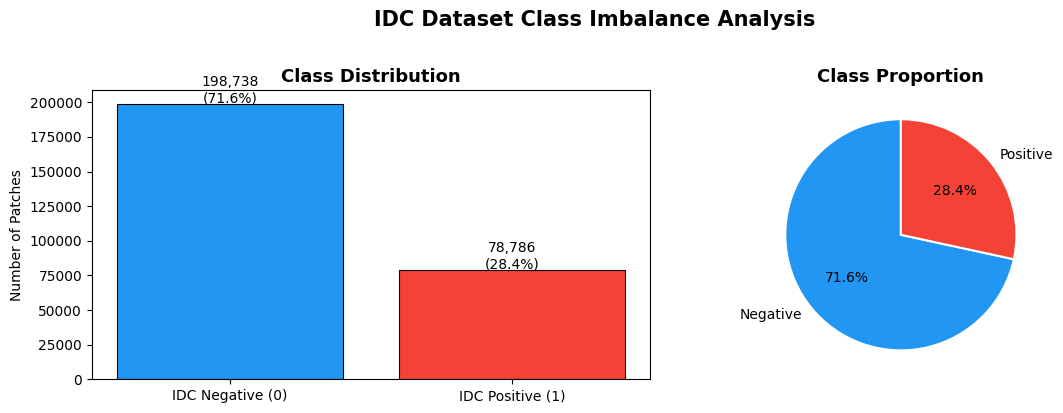

Imbalance ratio (neg:pos) = 2.52:1


In [3]:
# Class Imbalance Analysis
#Class weights are intended to prevent model from being more likely to predict one class over the other
n_neg, n_pos = len(neg_paths), len(pos_paths)
total = n_neg + n_pos
imbalance_ratio = n_neg / n_pos

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(['IDC Negative (0)', 'IDC Positive (1)'], [n_neg, n_pos],
            color=['#2196F3', '#F44336'], edgecolor='black', linewidth=0.8)
axes[0].set_title('Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Number of Patches')
for i, v in enumerate([n_neg, n_pos]):
    axes[0].text(i, v + 1500, f'{v:,}\n({v/total*100:.1f}%)',
                 ha='center', fontsize=10)
# Pie chart
axes[1].pie([n_neg, n_pos], labels=['Negative', 'Positive'],
            autopct='%1.1f%%', colors=['#2196F3','#F44336'],
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=1.5))
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')
plt.suptitle('IDC Dataset Class Imbalance Analysis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Imbalance ratio (neg:pos) = {imbalance_ratio:.2f}:1')

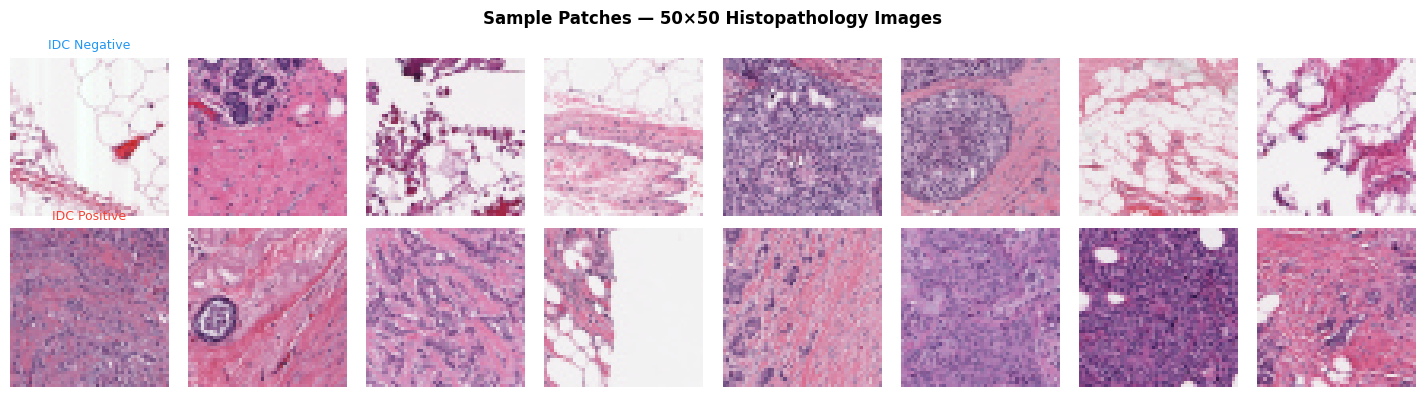

In [4]:
# Visually inspect patches before building the pipeline
def show_sample_grid(paths_0, paths_1, n=8):
    fig, axes = plt.subplots(2, n, figsize=(n*1.8, 4))
    for i, p in enumerate(random.sample(paths_0, n)):
        img = plt.imread(str(p))
        axes[0, i].imshow(img)
        axes[0, i].axis('off')
        if i == 0: axes[0, i].set_title('IDC Negative', fontsize=9, color='#2196F3')
    for i, p in enumerate(random.sample(paths_1, n)):
        img = plt.imread(str(p))
        axes[1, i].imshow(img)
        axes[1, i].axis('off')
        if i == 0: axes[1, i].set_title('IDC Positive', fontsize=9, color='#F44336')
    plt.suptitle('Sample Patches — 50×50 Histopathology Images', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('sample_patches.png', dpi=150, bbox_inches='tight')
    plt.show()

show_sample_grid(neg_paths, pos_paths, n=8)


## 3. Dataset Splitting Strategy <a id='3'></a>

**Design Decisions:**

| Split | Proportion | Purpose |
|-------|-----------|--------|
| Train | 70% | Gradient updates |
| Validation | 15% | Hyperparameter tuning / early stopping |
| Test | 15% | Final unbiased evaluation |

Usually I would employ an 80%, 10%, 10% split however the size of the dataset means its worth dedicating more resources to fortifying the validation and test portions.

Data splitting is done at the Patient ID level to prevent data leakage.

In [5]:
# Building path and label arrays
all_paths  = [str(p) for p in neg_paths + pos_paths]
all_labels = [0]*len(neg_paths) + [1]*len(pos_paths)

combined= list(zip(all_paths, all_labels))
random.shuffle(combined)
all_paths, all_labels = zip(*combined)
all_paths, all_labels = list(all_paths), list(all_labels)

# Patient-wise split
# The format for each patch is<patientID>_xX_yY_classC.png.
#  Patients are split into train/val/test,
# then assign all patches from each patient to their respective split.

def extract_patient_id(path):
    """Extract patient-level ID from patch path. E.g. '10253_idx5'"""
    fname = os.path.basename(path)          # e.g. 10253_idx5_x1351_y1101_class0.png
    parts = fname.split('_')
    # Patient ID = everything before the first '_x' token
    pid = ''
    for i, part in enumerate(parts):
        if part.startswith('x') and part[1:].isdigit():
            break
        pid += ('_' if pid else '') + part
    return pid

# Get unique patients and reproduce split compositions
patient_ids = [extract_patient_id(p) for p in all_paths]

# Saved patient split for any runs and trainings that follow
split_file = pathlib.Path('patient_split.json')
if split_file.exists():
    with open(split_file) as f:
        split = json.load(f)
        train_patients = set(split['train'])
        val_patients = set(split['val'])
        test_patients = set(split['test'])
    print(f"Loaded saved patient split from {split_file}.")
else:
    unique_patients = sorted(set(patient_ids))
    rng = random.Random(SEED)                   # Dedicated generator
    rng.shuffle(unique_patients)
    n_train_p = int(0.70 * len(unique_patients))
    n_val_p   = int(0.15 * len(unique_patients))
    train_patients = set(unique_patients[:n_train_p])
    val_patients   = set(unique_patients[n_train_p:n_train_p + n_val_p])
    test_patients  = set(unique_patients[n_train_p + n_val_p:])
    with open(split_file, 'w') as f:
        json.dump({'train': sorted(train_patients),
                   'val': sorted(val_patients),
                   'test': sorted(test_patients)}, f, indent=2)
    print(f"Unique patients in dataset: {len(set(patient_ids))} -> "
          f"train {len(train_patients)}, val {len(val_patients)}, test {len(test_patients)}")

# Sanity check ensuring no patient appears in multiple splits
assert train_patients.isdisjoint(val_patients)
assert train_patients.isdisjoint(test_patients)
assert val_patients.isdisjoint(test_patients)
# Makes sure that split file matches dataset on disk
assert (train_patients | val_patients | test_patients) == set(patient_ids)

# Assign patches to splits based on patient membership
train_paths, train_labels = [], []
val_paths,   val_labels   = [], []
test_paths,  test_labels  = [], []

for path, label, pid in zip(all_paths, all_labels, patient_ids):
    if pid in train_patients:
        train_paths.append(path); train_labels.append(label)
    elif pid in val_patients:
        val_paths.append(path);   val_labels.append(label)
    else:
        test_paths.append(path);  test_labels.append(label)

print(f'\nSplit sizes:')
print(f'  Train : {len(train_paths):>7,}  ({len(train_paths)/len(all_paths)*100:.1f}%)')
print(f'  Val   : {len(val_paths):>7,}  ({len(val_paths)/len(all_paths)*100:.1f}%)')
print(f'  Test  : {len(test_paths):>7,}  ({len(test_paths)/len(all_paths)*100:.1f}%)')

# Inspect class balance in each split
for name, labels in [('Train', train_labels), ('Val', val_labels), ('Test', test_labels)]:
    c = Counter(labels)
    print(f'  {name} pos rate: {c[1]/(c[0]+c[1])*100:.1f}%')

Loaded saved patient split from patient_split.json.

Split sizes:
  Train : 201,231  (72.5%)
  Val   :  36,811  (13.3%)
  Test  :  39,482  (14.2%)
  Train pos rate: 29.8%
  Val pos rate: 30.2%
  Test pos rate: 19.3%


In [ ]:
# import shutil
# import random
#
# random.seed(SEED)  # keep this consistent too, for reproducible sample selection
# test_pairs = list(zip(test_paths, test_labels))
# random.shuffle(test_pairs)
#
# benign_samples = [p for p, l in test_pairs if l == 0][:3]
# malignant_samples = [p for p, l in test_pairs if l == 1][:3]
#
# import os
# os.makedirs("sample_images", exist_ok=True)
#
# for i, path in enumerate(benign_samples):
#     shutil.copy(path, f"sample_images/benign_example_{i}.png")
# for i, path in enumerate(malignant_samples):
#     shutil.copy(path, f"sample_images/malignant_example_{i}.png")

In [6]:
# Class weights (for imbalance compensation)

n_train_neg = train_labels.count(0)
n_train_pos = train_labels.count(1)
n_train_total = len(train_labels)

weight_neg = n_train_total / (2 * n_train_neg)
weight_pos = n_train_total / (2 * n_train_pos)
class_weights = {0: weight_neg, 1: weight_pos}

print(f'Class weights  →  0 (Neg): {weight_neg:.4f}  |  1 (Pos): {weight_pos:.4f}')
print(f'Effective amplification of positive class: {weight_pos/weight_neg:.2f}×')

Class weights  →  0 (Neg): 0.7127  |  1 (Pos): 1.6756
Effective amplification of positive class: 2.35×


## 4. Data Pipeline  <a id='4'></a>

Key advantages of using `tf.data` method:

- **Prefetching:** While the GPU trains on batch N, the CPU is already decoding batch N+1. This hides I/O latency almost completely.
- **Parallel map:** Multi-threaded image decoding using `num_parallel_calls=AUTOTUNE`.
- **Memory-mapped:** Images are read from disk in a streaming fashion so it's never the entire dataset never entering RAM.
- **Caching:** After the first epoch, decoded tensors can be cached in RAM or in a `.cache` file on disk, eliminating repeated I/O.

**Batch size = 32** is suited to the available VRAM. It will give noisier gradients but better generalisation.

In [7]:
AUTOTUNE = tf.data.AUTOTUNE

def parse_image(path, label):
    """
    Read a PNG from disk, decode it to float32 in [0,1].
    Resizes to IMG_SIZE to handle any non-standard patches gracefully.
    """
    raw = tf.io.read_file(path)

    # Decode
    #Use expand_animations=False for safety with some PNG encoders
    image = tf.image.decode_png(raw, channels=CHANNELS)
    image = tf.image.convert_image_dtype(image, tf.float32)

    # This normalises any patch that isn't exactly 50×50 for whatever reason
    image = tf.image.resize(image, IMG_SIZE)

    return image, label

def make_dataset(paths, labels, training=False, cache=False):
    """
    Build a tf.data pipeline from path/label lists.
    training=True enables shuffle + augmentation.
    cache=True caches decoded images in RAM after epoch 1 (use if RAM > 12 GB).
    """
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    
    if training:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED, reshuffle_each_iteration=True)
    
    ds = ds.map(parse_image, num_parallel_calls=AUTOTUNE)
    
    if cache:
        ds = ds.cache()  # Uncomment .cache('cache_train') to use a disk cache instead
    
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(AUTOTUNE)  # Key performance gain: overlaps CPU/GPU work
    return ds


train_ds = make_dataset(train_paths, train_labels, training=True,  cache=False)
val_ds   = make_dataset(val_paths,   val_labels,   training=False, cache=False)
test_ds  = make_dataset(test_paths,  test_labels,  training=False, cache=False)

# Sanity check
for images, labels_batch in train_ds.take(1):
    print(f'Batch shape : {images.shape}')
    print(f'Label shape : {labels_batch.shape}')
    print(f'Pixel range : [{images.numpy().min():.3f}, {images.numpy().max():.3f}]')
    print(f'Batch pos%  : {labels_batch.numpy().mean()*100:.1f}%')

I0000 00:00:1791153991.647515    1591 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1791153991.647790    1591 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1791153991.647818    1591 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1791153991.973974    1591 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1791153991.974717    1591 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Batch shape : (32, 50, 50, 3)
Label shape : (32,)
Pixel range : [0.020, 0.988]
Batch pos%  : 37.5%


## 5. Image Preprocessing & Augmentation <a id='5'></a>

Augmentation reduces overfitting by artificially expanding the dataset introducing a generalisation so for example input orientation won't affect model performance. **Note** that augmentation will **only** apply to the training set.

Augmentation selected based on their suitability:
- Random horizontal/vertical flips → slides can be scanned regardless of orientation
- Random rotation (~20°) → slides can be scanned at any angle
- Random zoom (5%) → kept low to avoid spatial structure destruction
- Random brightness/contrast → simulating discrepancies in staining from multiple sources

Excluded:
- Hue shift → H&E colour (purple/pink) is diagnostically meaningful, aggressively changing colours wouldn't make sense
- Cutout / MixUp → these destroy spatial structure on the low resolution patches used

Augmentation layers are embedded in the model graph, so they:
1. Run on GPU (fast)
2. Are automatically disabled during prediction or evaluation

Simple `[0,1]` or per-batch standardisation (`(x - mean) / std`) is appropriate here. Used a `Normalisation` layer learned from the training data for the best results.

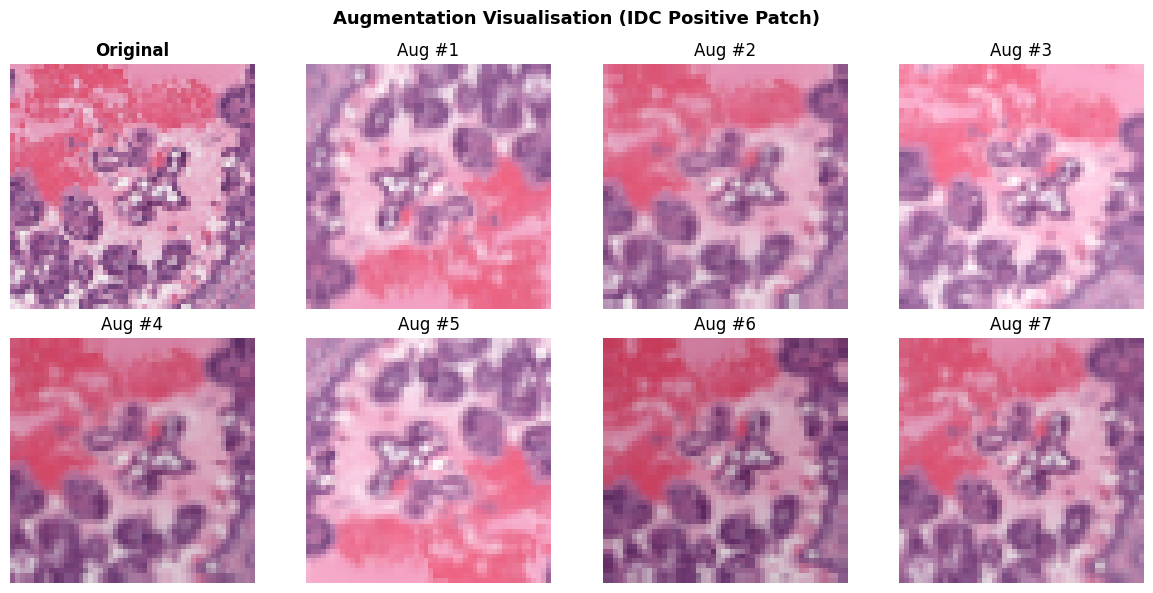

In [8]:
# Augmentation
augment = keras.Sequential([
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(factor=0.055),
    layers.RandomZoom(height_factor=0.05, width_factor=0.05),
    layers.RandomBrightness(factor=0.1, value_range=(0.0, 1.0)),
    layers.RandomContrast(factor=0.1, value_range=(0.0, 1.0)),
], name='augmentation')

# Load sample image as float32 explicitly — never let matplotlib touch float16
sample_img = plt.imread(str(random.choice(pos_paths)))

# Convert to float32 in [0,1] range
if sample_img.dtype == np.uint8:
    sample_img = sample_img.astype(np.float32) / 255.0
else:
    sample_img = sample_img.astype(np.float32)

# Wrap in batch dimension — keep as float32 throughout
sample_tensor = tf.constant(sample_img[np.newaxis, ...], dtype=tf.float32)

# Below is to visualise the augmentation effects on a sample
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
axes = axes.flatten()

axes[0].imshow(sample_img)          # Already float32 — safe
axes[0].set_title('Original', fontweight='bold')
axes[0].axis('off')

for i in range(1, 8):
    aug = augment(sample_tensor, training=True)
    # Cast output to float32 regardless of global dtype policy, then clip
    aug_np = tf.cast(aug[0], tf.float32).numpy()
    aug_np = np.clip(aug_np, 0.0, 1.0)
    axes[i].imshow(aug_np)          # float32 — matplotlib is happy
    axes[i].set_title(f'Aug #{i}')
    axes[i].axis('off')

plt.suptitle('Augmentation Visualisation (IDC Positive Patch)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('augmentation_preview.png', dpi=150, bbox_inches='tight')

In [9]:
# Computing the training-set stats for normalisation
# Sample is explicitly cast to float32 before adapting.
# The Normalisation layer's internal state is float32, which conflicts with
# the global mixed_float16 policy applied to pipeline tensors.
# Adapting here won't interfere with training ops as it's a one time stat snapshot

normaliser = layers.Normalization(axis=-1, dtype='float32')

# Cast to float32 explicitly before adapting
sample_ds = (
    train_ds
    .take(50)
    .map(lambda x, y: tf.cast(x, tf.float32))
    .unbatch()                                    
)

normaliser.adapt(sample_ds)
print('Normaliser fitted.')
print(f'  Channel means : {normaliser.mean.numpy().flatten()}')
print(f'  Channel vars  : {normaliser.variance.numpy().flatten()}')

Normaliser fitted.
  Channel means : [0.810506   0.62861764 0.7299105 ]
  Channel vars  : [0.02007261 0.04422282 0.0230059 ]


## 6. Model Architecture <a id='6'></a>

### Architectural considerations

**Input image size: 50×50×3.**  I've built a custom lightweight CNN specifically calibrated for 50×50 medical patches which would otherwise cause spatial destruction in the early stages of pooling on a more heavyweight CNN architecture for e.g. ResNet50.

### Design Decisions

| Decision | Choice                          |    |
|----------|---------------------------------|------------------------------------------------------------------------------------------------------------------------|
| Depth | 4 Conv blocks                   | |
| Filters | 32→64→128→256                   |
| Kernel | 3×3                             |
| Pooling | MaxPool 2×2                     |
| Activation | ReLU                            |
| BatchNorm | After each Conv                 |
| Dropout | 0.4 and 0.3 (dense), 0.2 (conv) |
| L2 regularisation | 1e-4                            |
| Global Avg Pool | Before FC                       |
| Dense head | 256 → 128 → 1                   |
| Output | Sigmoid                         |

 Total parameter estimate: ~1.28M (lightweight, appropriate for 50×50px inputs)

In [10]:
# Custom cast layers with serialization decorators for Keras 3 compatibility

@keras.saving.register_keras_serializable()
class CastToFloat32(keras.layers.Layer):
    def call(self, x):
        return keras.ops.cast(x, 'float32')

@keras.saving.register_keras_serializable()
class CastToFloat16(keras.layers.Layer):
    def call(self, x):
        return keras.ops.cast(x, 'float16')


def build_idc_cnn(input_shape=(50, 50, 3)):
    """
    Custom CNN for IDC binary classification.
    Keras 3 compatible — all ops go through keras.layers or keras.ops.
    Architecture: Cast → Augment →  Normalise → Cast → 4 ConvBlocks → GAP → Dense → Sigmoid
    """
    inputs = keras.Input(shape=input_shape, name='input_patch')

    # Preprocessing
    # Must cast via a Layer subclass, not tf.cast, in Keras 3 Functional API
    # Post augmentation and normalisation casts are not entirely necessary, down to personal preference
    x = CastToFloat32(name='cast_to_f32')(inputs)
    x = augment(x)                               # Augmentation
    x = CastToFloat32(name='cast_aug_to_f32')(x)
    x = normaliser(x)                           # Normalisation layer
    x = CastToFloat16(name='cast_to_f16')(x)        # Back to float16 for conv ops

    # Block 1: 50×50 → 25×25
    x = layers.Conv2D(32, (3,3), padding='same', use_bias=False, name='conv1a')(x)
    x = layers.BatchNormalization(name='bn1a')(x)
    x = layers.Activation('relu', name='relu1a')(x)
    x = layers.Conv2D(32, (3,3), padding='same', use_bias=False, name='conv1b')(x)
    x = layers.BatchNormalization(name='bn1b')(x)
    x = layers.Activation('relu', name='relu1b')(x)
    x = layers.MaxPooling2D((2,2), name='pool1')(x)
    x = layers.SpatialDropout2D(0.2, name='sdrop1')(x)

    # Block 2: 25×25 → 12×12
    x = layers.Conv2D(64, (3,3), padding='same', use_bias=False, name='conv2a')(x)
    x = layers.BatchNormalization(name='bn2a')(x)
    x = layers.Activation('relu', name='relu2a')(x)
    x = layers.Conv2D(64, (3,3), padding='same', use_bias=False, name='conv2b')(x)
    x = layers.BatchNormalization(name='bn2b')(x)
    x = layers.Activation('relu', name='relu2b')(x)
    x = layers.MaxPooling2D((2,2), name='pool2')(x)
    x = layers.SpatialDropout2D(0.2, name='sdrop2')(x)

    # Block 3: 12×12 → 6×6
    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False, name='conv3a')(x)
    x = layers.BatchNormalization(name='bn3a')(x)
    x = layers.Activation('relu', name='relu3a')(x)
    x = layers.Conv2D(128, (3,3), padding='same', use_bias=False, name='conv3b')(x)
    x = layers.BatchNormalization(name='bn3b')(x)
    x = layers.Activation('relu', name='relu3b')(x)
    x = layers.MaxPooling2D((2,2), name='pool3')(x)
    x = layers.SpatialDropout2D(0.2, name='sdrop3')(x)

    # Block 4: 6×6 → 3×3
    x = layers.Conv2D(256, (3,3), padding='same', use_bias=False, name='conv4a')(x)
    x = layers.BatchNormalization(name='bn4a')(x)
    x = layers.Activation('relu', name='relu4a')(x)
    x = layers.Conv2D(256, (3,3), padding='same', use_bias=False, name='conv4b')(x)
    x = layers.BatchNormalization(name='bn4b')(x)
    x = layers.Activation('relu', name='relu4b')(x)
    x = layers.MaxPooling2D((2,2), name='pool4')(x)

    # Global Average Pooling (GAP)
    x = layers.GlobalAveragePooling2D(name='gap')(x)

    # Dense Head
    x = layers.Dense(256, use_bias=False,
                     kernel_regularizer=regularizers.l2(1e-4), name='fc1')(x)
    x = layers.BatchNormalization(name='bn_fc1')(x)
    x = layers.Activation('relu', name='relu_fc1')(x)
    x = layers.Dropout(0.4, name='drop1')(x)

    x = layers.Dense(128, use_bias=False,
                     kernel_regularizer=regularizers.l2(1e-4), name='fc2')(x)
    x = layers.BatchNormalization(name='bn_fc2')(x)
    x = layers.Activation('relu', name='relu_fc2')(x)
    x = layers.Dropout(0.3, name='drop2')(x)

    # Output: explicitly float32 for numerical stability with mixed precision
    x = CastToFloat32(name='cast_output_f32')(x)
    outputs = layers.Dense(1, activation='sigmoid', dtype='float32', name='output')(x)

    model = keras.Model(inputs, outputs, name='IDC_CNN')
    return model


model = build_idc_cnn(input_shape=(50, 50, 3))
model.summary(line_length=80)

Model: "IDC_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                      ┃ Output Shape             ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_patch (InputLayer)          │ (None, 50, 50, 3)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ cast_to_f32 (CastToFloat32)       │ (None, 50, 50, 3)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ augmentation (Sequential)         │ (None, 50, 50, 3)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ cast_aug_to_f32 (CastToFloat32)   │ (None, 50, 50, 3)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ normalization (Normalization)     │ (None, 50, 50, 3)        │             7 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ cast_to_f16 (CastToFloat16)       │ (None, 50, 50, 3)        │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv1a (Conv2D)                   │ (None, 50, 50, 32)       │           864 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn1a (BatchNormalization)         │ (None, 50, 50, 32)       │           128 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ relu1a (Activation)               │ (None, 50, 50, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv1b (Conv2D)                   │ (None, 50, 50, 32)       │         9,216 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn1b (BatchNormalization)         │ (None, 50, 50, 32)       │           128 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ relu1b (Activation)               │ (None, 50, 50, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)              │ (None, 25, 25, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ sdrop1 (SpatialDropout2D)         │ (None, 25, 25, 32)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2a (Conv2D)                   │ (None, 25, 25, 64)       │        18,432 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn2a (BatchNormalization)         │ (None, 25, 25, 64)       │           256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ relu2a (Activation)               │ (None, 25, 25, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv2b (Conv2D)                   │ (None, 25, 25, 64)       │        36,864 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn2b (BatchNormalization)         │ (None, 25, 25, 64)       │           256 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ relu2b (Activation)               │ (None, 25, 25, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)              │ (None, 12, 12, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ sdrop2 (SpatialDropout2D)         │ (None, 12, 12, 64)       │             0 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ conv3a (Conv2D)                   │ (None, 12, 12, 128)      │        73,728 │
├───────────────────────────────────┼──────────────────────────┼───────────────┤
│ bn3a (BatchNormalization)    

 Total params: 1,275,112 (4.86 MB)

 Trainable params: 1,272,417 (4.85 MB)

 Non-trainable params: 2,695 (10.53 KB)

In [11]:
# Custom F1 metric compatible with binary output shape

class BinaryF1Score(keras.metrics.Metric):
    """
    F1 score for binary classification.
    Handles the (batch,) vs (batch, 1) shape mismatch that keras.metrics.F1Score
    cannot resolve for single-output sigmoid models.
    """
    def __init__(self, threshold=0.5, name='f1', **kwargs):
        super().__init__(name=name, **kwargs)
        self.threshold  = threshold
        self.true_pos   = self.add_weight(name='tp', initializer='zeros')
        self.false_pos  = self.add_weight(name='fp', initializer='zeros')
        self.false_neg  = self.add_weight(name='fn', initializer='zeros')

    def update_state(self, y_true, y_pred, sample_weight=None):
        y_pred = tf.cast(tf.squeeze(y_pred, axis=-1) >= self.threshold, tf.float32)
        y_true = tf.cast(tf.reshape(y_true, [-1]), tf.float32)
        self.true_pos.assign_add(tf.reduce_sum(y_true * y_pred))
        self.false_pos.assign_add(tf.reduce_sum((1 - y_true) * y_pred))
        self.false_neg.assign_add(tf.reduce_sum(y_true * (1 - y_pred)))

    def result(self):
        precision = self.true_pos / (self.true_pos + self.false_pos + 1e-7)
        recall    = self.true_pos / (self.true_pos + self.false_neg + 1e-7)
        return 2 * precision * recall / (precision + recall + 1e-7)

    def reset_state(self):
        self.true_pos.assign(0.)
        self.false_pos.assign(0.)
        self.false_neg.assign(0.)


# Compile portion
optimiser = keras.optimizers.AdamW(learning_rate=3e-4, weight_decay=1e-4)

model.compile(
    optimizer=optimiser,
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        BinaryF1Score(threshold=0.5, name='f1'),
    ]
)
print('Model compiled.')

Model compiled.


## 7. Training Strategy & Callbacks <a id='7'></a>

### Epochs Decision
- 50 chosen as an arbitrary upper bound, its expected that training will be completed well before this point
- Implemented `EarlyStopping` with patience of 8 for an automatic stopping at optimal epoch
- Any more training past the optimal point introduces the risk of overfitting

### Callback Stack

| Callback | Purpose                                                                             |
|----------|-------------------------------------------------------------------------------------|
| `EarlyStopping` | Governed by the `val_auc` metric. Implemented due to its independence. Patience = 8 |
| `ReduceLROnPlateau` | Halves LR when val_loss plateaus for 4 epochs                                       |
| `ModelCheckpoint` | Saves best model weights by `val_auc`                                               |
| `CSVLogger` | Logs all metrics per epoch to CSV for analysis afterwards                           |

### `val_auc` rationale as the observed metric:
AUC-ROC measures rank separation between classes regardless of the decision threshold. In a clinical application context, the clinician should be able to tinker the decision threshold based on desired sensitivity/specificity tradeoff.

*Include TensorBoard for training visualisation*

In [12]:
os.makedirs('checkpoints', exist_ok=True)
os.makedirs('logs', exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=8,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
     ReduceLROnPlateau(
        monitor='val_auc',
        mode='max',
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        filepath='checkpoints/idc_cnn_best.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    ),
    CSVLogger('logs/training_log.csv', append=False),
]

print('Callbacks configured. Starting training...')
print(f'Steps per epoch (train): {len(train_paths)//BATCH_SIZE}')
print(f'Steps per epoch (val)  : {len(val_paths)//BATCH_SIZE}')

Callbacks configured. Starting training...
Steps per epoch (train): 6288
Steps per epoch (val)  : 1150


In [13]:
# Ensuring cold start with fresh weights
train_start_time = time.time()
cold = model.evaluate(val_ds, verbose=0, return_dict=True)
print({k: round(float(v), 4) for k,v in cold.items()})
if cold['auc'] > 0.7:
    print('WARNING: AUC is well above 0.5 before any training, check that external weights have not contaminated current training')

W0000 00:00:1791154067.518696    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154067.566088    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154067.580928    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154067.593771    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154067.615867    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154067.629008    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154067.643727    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154067.714220    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154067.730506    1709 gp

{'accuracy': 0.698, 'auc': 0.4673, 'f1': 0.0, 'loss': 0.7342, 'precision': 0.0, 'recall': 0.0}


In [14]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50


W0000 00:00:1791154089.083504    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154089.097066    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154089.109774    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154089.122566    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154089.138300    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154089.151150    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154089.169705    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154089.190296    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154089.210370    1709 gp

   2/6289 ━━━━━━━━━━━━━━━━━━━━ 6:29 62ms/step - accuracy: 0.5234 - auc: 0.4262 - f1: 0.4183 - loss: 0.9474 - precision: 0.3727 - recall: 0.4811  

W0000 00:00:1791154091.142831    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154091.144682    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154091.146593    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154091.148184    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154091.149703    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154091.151511    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154091.153109    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154091.154651    1709 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154091.156487    1709 gp

6288/6289 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.7905 - auc: 0.8585 - f1: 0.6925 - loss: 0.5126 - precision: 0.6146 - recall: 0.7932

W0000 00:00:1791154477.233000    1707 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154477.254651    1707 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154477.257205    1707 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154477.258804    1707 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154477.261103    1707 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154477.263816    1707 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154477.266451    1707 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154477.268477    1707 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154477.270277    1707 gp

6289/6289 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step - accuracy: 0.7905 - auc: 0.8585 - f1: 0.6925 - loss: 0.5125 - precision: 0.6146 - recall: 0.7932

W0000 00:00:1791154479.309550    1713 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154479.312165    1713 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154479.314070    1713 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154479.315898    1713 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154479.317454    1713 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154479.319222    1713 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154479.320755    1713 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154479.322298    1713 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791154479.324124    1713 gp


Epoch 1: val_auc improved from None to 0.91155, saving model to checkpoints/idc_cnn_best.keras
6289/6289 ━━━━━━━━━━━━━━━━━━━━ 412s 64ms/step - accuracy: 0.8075 - auc: 0.8817 - f1: 0.7175 - loss: 0.4706 - precision: 0.6383 - recall: 0.8193 - val_accuracy: 0.8075 - val_auc: 0.9116 - val_f1: 0.7380 - val_loss: 0.4911 - val_precision: 0.6265 - val_recall: 0.8976 - learning_rate: 3.0000e-04
Epoch 2/50
6289/6289 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.8277 - auc: 0.9031 - f1: 0.7460 - loss: 0.4157 - precision: 0.6680 - recall: 0.8446
Epoch 2: val_auc improved from 0.91155 to 0.92325, saving model to checkpoints/idc_cnn_best.keras
6289/6289 ━━━━━━━━━━━━━━━━━━━━ 431s 68ms/step - accuracy: 0.8310 - auc: 0.9059 - f1: 0.7492 - loss: 0.4054 - precision: 0.6722 - recall: 0.8462 - val_accuracy: 0.8409 - val_auc: 0.9232 - val_f1: 0.7680 - val_loss: 0.3851 - val_precision: 0.6861 - val_recall: 0.8721 - learning_rate: 3.0000e-04
Epoch 3/50
6289/6289 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy

## 8. Model Evaluation <a id='8'></a>

In [15]:
# Loading the best checkpoint with ch
custom_objects = {
    'CastToFloat32': CastToFloat32,
    'CastToFloat16': CastToFloat16,
    'BinaryF1Score': BinaryF1Score
}
ckpt_path = 'checkpoints/idc_cnn_best.keras'
if 'train_start_time' in globals():
    assert os.path.getmtime(ckpt_path) >= train_start_time, 'Checkpoint is older than this training run. Stale weights will not be loaded'
else:
    print("NOTE: training start time unknown. Check manually for the checkpoint timestamps.")

# Load model with custom_objects
best_model = keras.models.load_model(
    'checkpoints/idc_cnn_best.keras',
    custom_objects=custom_objects
)


# Test set evaluation
print('Evaluating on test set...')
test_results = best_model.evaluate(test_ds, verbose=1)
metric_names = best_model.metrics_names
print('\n' + '='*50)
print('TEST SET METRICS')
print('='*50)
for name, val in zip(metric_names, test_results):
    print(f'  {name:<15}: {val:.4f}')

Evaluating on test set...
1230/1234 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8606 - auc: 0.9481 - f1: 0.7145 - loss: 0.3251 - precision: 0.5882 - recall: 0.9101

W0000 00:00:1791168231.924691    1714 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168232.058370    1714 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168232.060517    1714 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168232.062305    1714 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168232.065734    1714 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168232.072665    1714 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168232.075782    1714 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168232.077641    1714 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168232.079354    1714 gp

1234/1234 ━━━━━━━━━━━━━━━━━━━━ 46s 16ms/step - accuracy: 0.8648 - auc: 0.9518 - f1: 0.7236 - loss: 0.3168 - precision: 0.5976 - recall: 0.9171

TEST SET METRICS
  loss           : 0.3168
  compile_metrics: 0.8648


In [16]:
# Gather predictions
y_prob = best_model.predict(test_ds, verbose = 0).flatten()
y_true = np.array(test_labels)
assert len(y_prob) == len(y_true), 'Prediction or label length mismatch'
y_pred = (y_prob >= 0.5).astype(int)

print(f'Test samples: {len(y_true):,}')
print(f'Positive predictions: {y_pred.sum():,} ({y_pred.mean()*100:.1f}%)')

Test samples: 39,482
Positive predictions: 11,694 (29.6%)


In [17]:
# Classification report
print('\nClassification Report:')
print(classification_report(y_true, y_pred,
                             target_names=['IDC Negative (0)', 'IDC Positive (1)'],
                             digits=4))


Classification Report:
                  precision    recall  f1-score   support

IDC Negative (0)     0.9773    0.8523    0.9105     31862
IDC Positive (1)     0.5976    0.9171    0.7236      7620

        accuracy                         0.8648     39482
       macro avg     0.7874    0.8847    0.8171     39482
    weighted avg     0.9040    0.8648    0.8744     39482




## 9. Visualisation & Explainability <a id='9'></a>

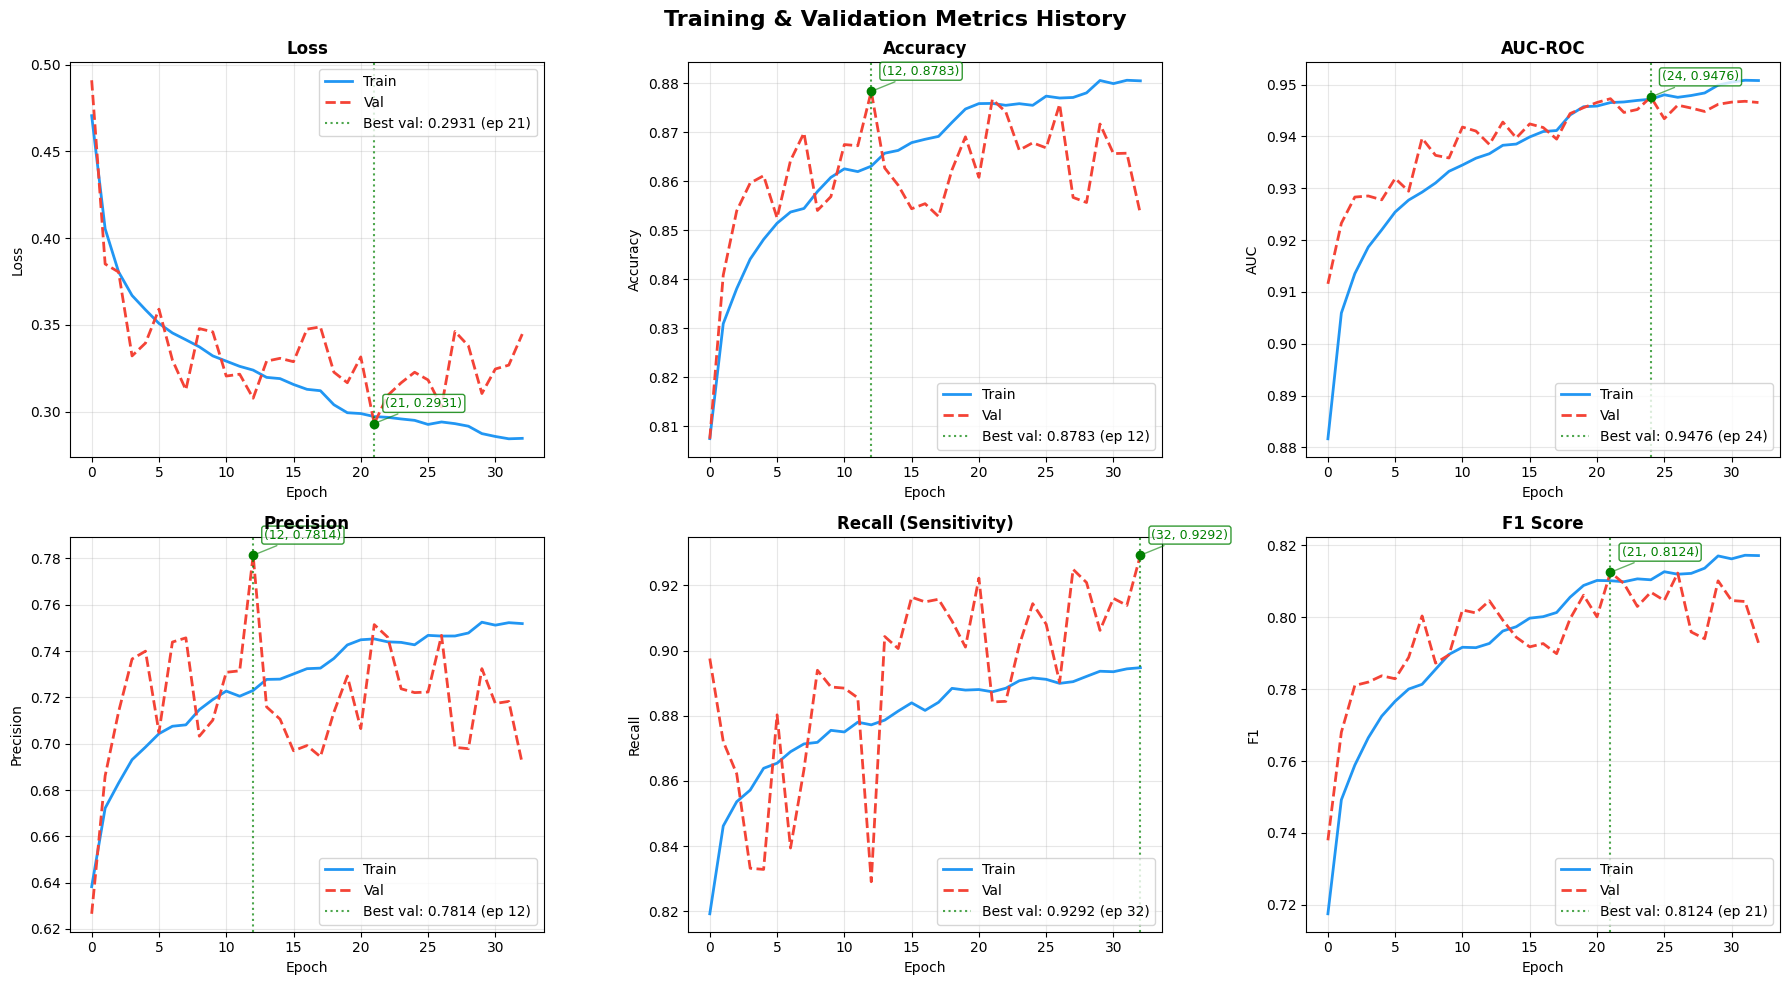

In [18]:
# Training history curves
hist = pd.read_csv('logs/training_log.csv')

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

plot_pairs = [
    ('loss',      'val_loss',      'Loss',            'Loss'),
    ('accuracy',  'val_accuracy',  'Accuracy',        'Accuracy'),
    ('auc',       'val_auc',       'AUC-ROC',         'AUC'),
    ('precision', 'val_precision', 'Precision',       'Precision'),
    ('recall',    'val_recall',    'Recall (Sensitivity)', 'Recall'),
    ('f1',        'val_f1',        'F1 Score',        'F1'),
]

for ax, (train_m, val_m, title, ylabel) in zip(axes, plot_pairs):
    ax.plot(hist[train_m],   label='Train', linewidth=2, color='#2196F3')
    ax.plot(hist[val_m],     label='Val',   linewidth=2, color='#F44336', linestyle='--')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    # Mark best val epoch
    if 'loss' in val_m:
        best_e = hist[val_m].idxmin()
    else:
        best_e = hist[val_m].idxmax()
    best_v = hist[val_m].loc[best_e]    # metric value at the best epoch

    ax.axvline(x=best_e, color='green', linestyle=':', alpha=0.7,
               label=f'Best val: {best_v:.4f} (ep {best_e})')
    ax.scatter(best_e, best_v, color='green', zorder=5)
    ax.annotate(f'({best_e}, {best_v:.4f})', xy=(best_e, best_v),
                xytext=(8, 12), textcoords='offset points',
                fontsize=9, color='green',
                bbox=dict(boxstyle='round,pad=0.2', fc='white', ec='green', alpha=0.8),
                arrowprops=dict(arrowstyle='-', color='green', alpha=0.6),
                annotation_clip=False)
    ax.legend()

plt.suptitle('Training & Validation Metrics History', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()

TN: 27,156  |  FP: 4,706  |  FN: 632  |  TP: 6,988
Sensitivity (Recall): 0.9171
Specificity         : 0.8523


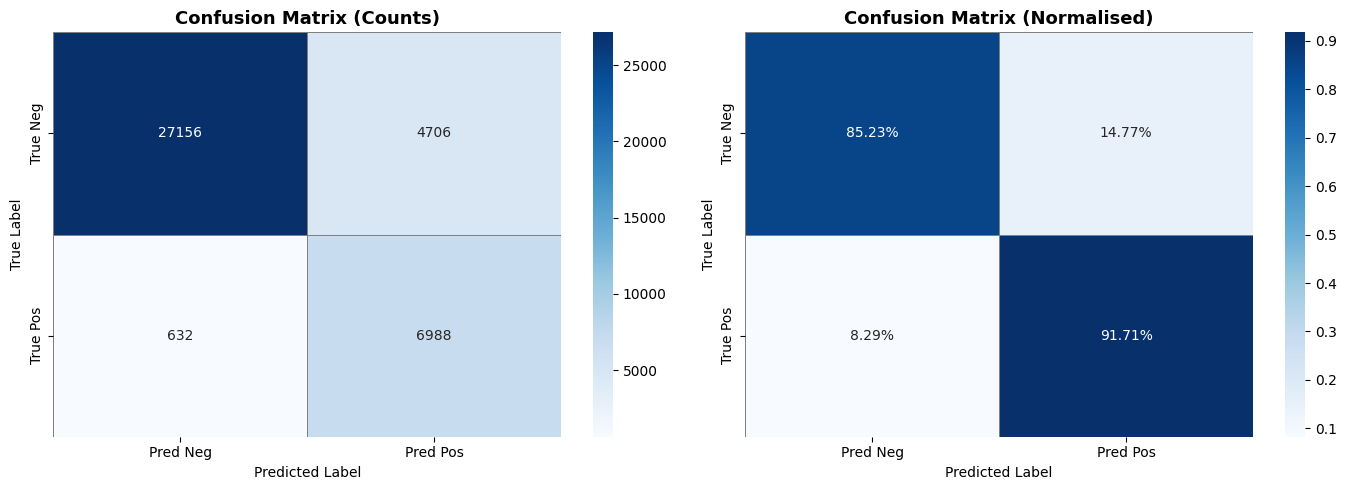

In [19]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in [
    (axes[0], cm,      'd',    'Confusion Matrix (Counts)'),
    (axes[1], cm_norm, '.2%',  'Confusion Matrix (Normalised)'),
]:
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=['Pred Neg', 'Pred Pos'],
                yticklabels=['True Neg', 'True Pos'],
                linewidths=0.5, linecolor='gray')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')

tn, fp, fn, tp = cm.ravel()
print(f'TN: {tn:,}  |  FP: {fp:,}  |  FN: {fn:,}  |  TP: {tp:,}')
print(f'Sensitivity (Recall): {tp/(tp+fn):.4f}')
print(f'Specificity         : {tn/(tn+fp):.4f}')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

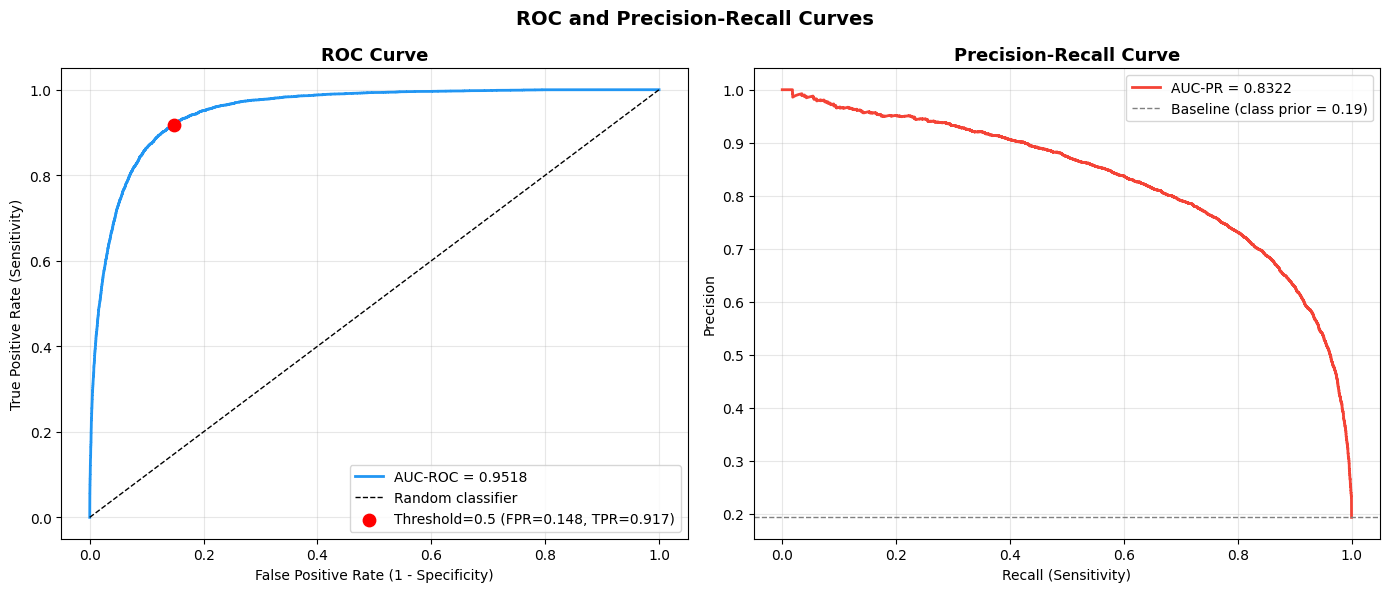

AUC-ROC: 0.9518
AUC-PR : 0.8322


In [20]:
# ROC and PR curves
fpr, tpr, roc_thresholds = roc_curve(y_true, y_prob)
roc_auc_val = auc(fpr, tpr)

precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_true, y_prob)
pr_auc_score = average_precision_score(y_true, y_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC
axes[0].plot(fpr, tpr, color='#2196F3', lw=2,
             label=f'AUC-ROC = {roc_auc_val:.4f}')
axes[0].plot([0,1],[0,1], 'k--', lw=1, label='Random classifier')
# Mark operating point at threshold=0.5
idx = np.argmin(np.abs(roc_thresholds - 0.5))
axes[0].scatter(fpr[idx], tpr[idx], color='red', s=80, zorder=5,
                label=f'Threshold=0.5 (FPR={fpr[idx]:.3f}, TPR={tpr[idx]:.3f})')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)')
axes[0].set_ylabel('True Positive Rate (Sensitivity)')
axes[0].set_title('ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

# Precision-Recall
axes[1].plot(recall_curve, precision_curve, color='#F44336', lw=2,
             label=f'AUC-PR = {pr_auc_score:.4f}')
baseline = y_true.mean()
axes[1].axhline(y=baseline, color='gray', linestyle='--', lw=1,
                label=f'Baseline (class prior = {baseline:.2f})')
axes[1].set_xlabel('Recall (Sensitivity)')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('ROC and Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC-ROC: {roc_auc_val:.4f}')
print(f'AUC-PR : {pr_auc_score:.4f}')

Optimal threshold (Youden J, chosen on the validation set): 0.6007

At threshold = 0.6007:
              precision    recall  f1-score   support

IDC Negative     0.9698    0.8850    0.9255     31862
IDC Positive     0.6480    0.8848    0.7481      7620

    accuracy                         0.8850     39482
   macro avg     0.8089    0.8849    0.8368     39482
weighted avg     0.9077    0.8850    0.8912     39482



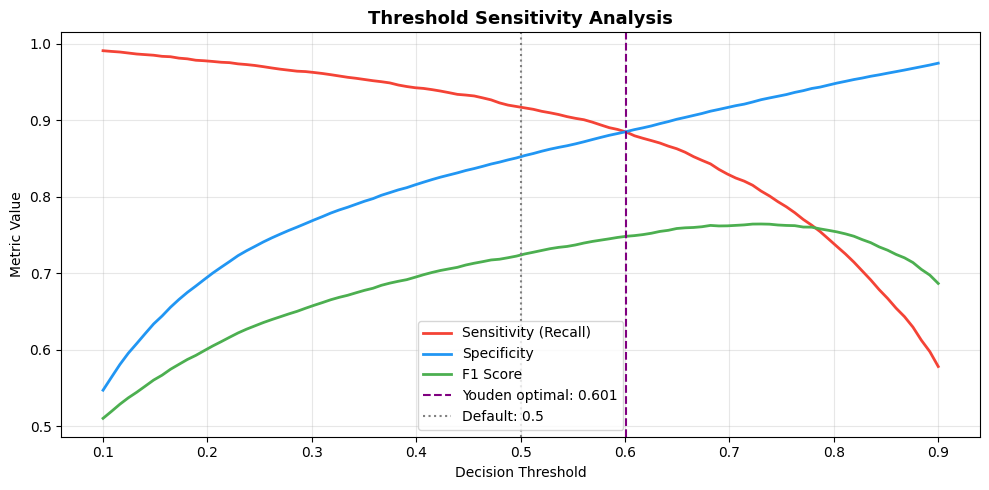

In [21]:
# Threshold Optimisation

# Youden threshold is chosen based on the validation set and applied on the test set
y_val_true = np.array(val_labels)
y_val_prob = best_model.predict(val_ds, verbose=0).flatten()
fpr_val, tpr_val, thr_val = roc_curve(y_val_true, y_val_prob)
best_threshold = thr_val[np.argmax(tpr_val - fpr_val)]

y_pred_opt = (y_prob >= best_threshold).astype(int)

print(f'Optimal threshold (Youden J, chosen on the validation set): {best_threshold:.4f}')   # ***
print(f'\nAt threshold = {best_threshold:.4f}:')
print(classification_report(y_true, y_pred_opt,
                             target_names=['IDC Negative', 'IDC Positive'], digits=4))

# Threshold sensitivity plot
thresholds_range = np.linspace(0.1, 0.9, 100)
sensitivities, specificities, f1s = [], [], []
for t in thresholds_range:
    yp = (y_prob >= t).astype(int)
    tn_t, fp_t, fn_t, tp_t = confusion_matrix(y_true, yp).ravel()
    sensitivities.append(tp_t/(tp_t+fn_t) if (tp_t+fn_t) > 0 else 0)
    specificities.append(tn_t/(tn_t+fp_t) if (tn_t+fp_t) > 0 else 0)
    f1s.append(2*tp_t/(2*tp_t+fp_t+fn_t) if (2*tp_t+fp_t+fn_t) > 0 else 0)

plt.figure(figsize=(10, 5))
plt.plot(thresholds_range, sensitivities, label='Sensitivity (Recall)', color='#F44336', lw=2)
plt.plot(thresholds_range, specificities, label='Specificity',          color='#2196F3', lw=2)
plt.plot(thresholds_range, f1s,           label='F1 Score',             color='#4CAF50', lw=2)
plt.axvline(x=best_threshold, color='purple', linestyle='--',
            label=f'Youden optimal: {best_threshold:.3f}')
plt.axvline(x=0.5, color='gray', linestyle=':', label='Default: 0.5')
plt.xlabel('Decision Threshold')
plt.ylabel('Metric Value')
plt.title('Threshold Sensitivity Analysis', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

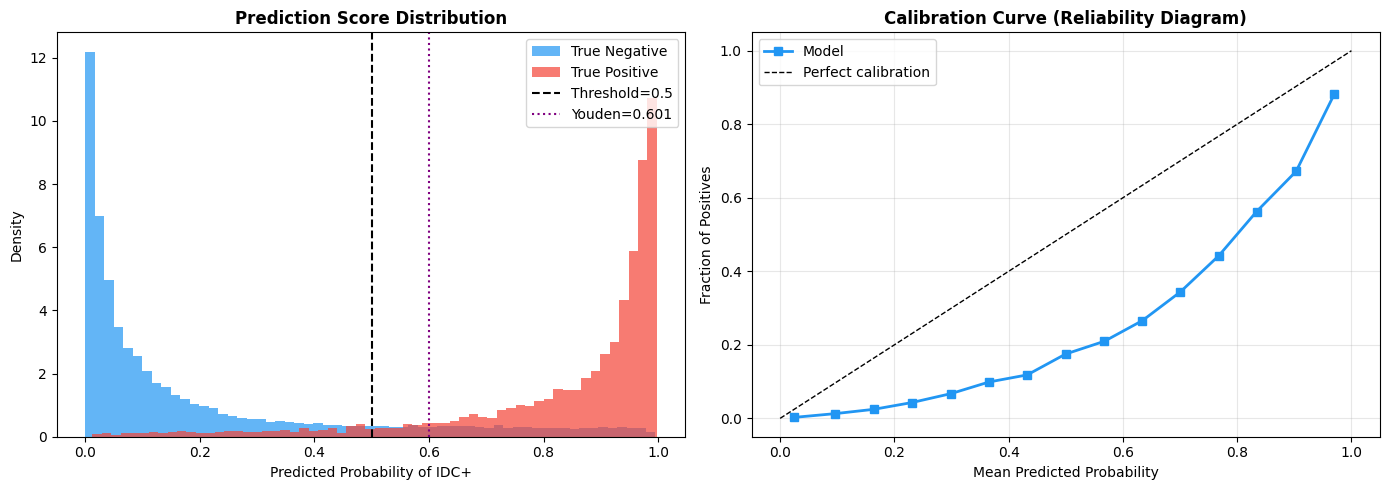

In [22]:
# Prediction probability distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

neg_probs = y_prob[y_true == 0]
pos_probs = y_prob[y_true == 1]

axes[0].hist(neg_probs, bins=60, color='#2196F3', alpha=0.7, label='True Negative', density=True)
axes[0].hist(pos_probs, bins=60, color='#F44336', alpha=0.7, label='True Positive', density=True)
axes[0].axvline(x=0.5, color='black', linestyle='--', label='Threshold=0.5')
axes[0].axvline(x=best_threshold, color='purple', linestyle=':', label=f'Youden={best_threshold:.3f}')
axes[0].set_xlabel('Predicted Probability of IDC+')
axes[0].set_ylabel('Density')
axes[0].set_title('Prediction Score Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# Calibration curve
from sklearn.calibration import calibration_curve
prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=15)
axes[1].plot(prob_pred, prob_true, 's-', color='#2196F3', lw=2, label='Model')
axes[1].plot([0,1],[0,1], 'k--', lw=1, label='Perfect calibration')
axes[1].set_xlabel('Mean Predicted Probability')
axes[1].set_ylabel('Fraction of Positives')
axes[1].set_title('Calibration Curve (Reliability Diagram)', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('score_distribution_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

W0000 00:00:1791168264.649509    1591 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168264.660246    1591 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168264.668705    1591 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168264.676731    1591 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168264.685070    1591 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168264.693266    1591 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168264.702343    1591 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168264.711664    1591 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1791168264.720884    1591 gp

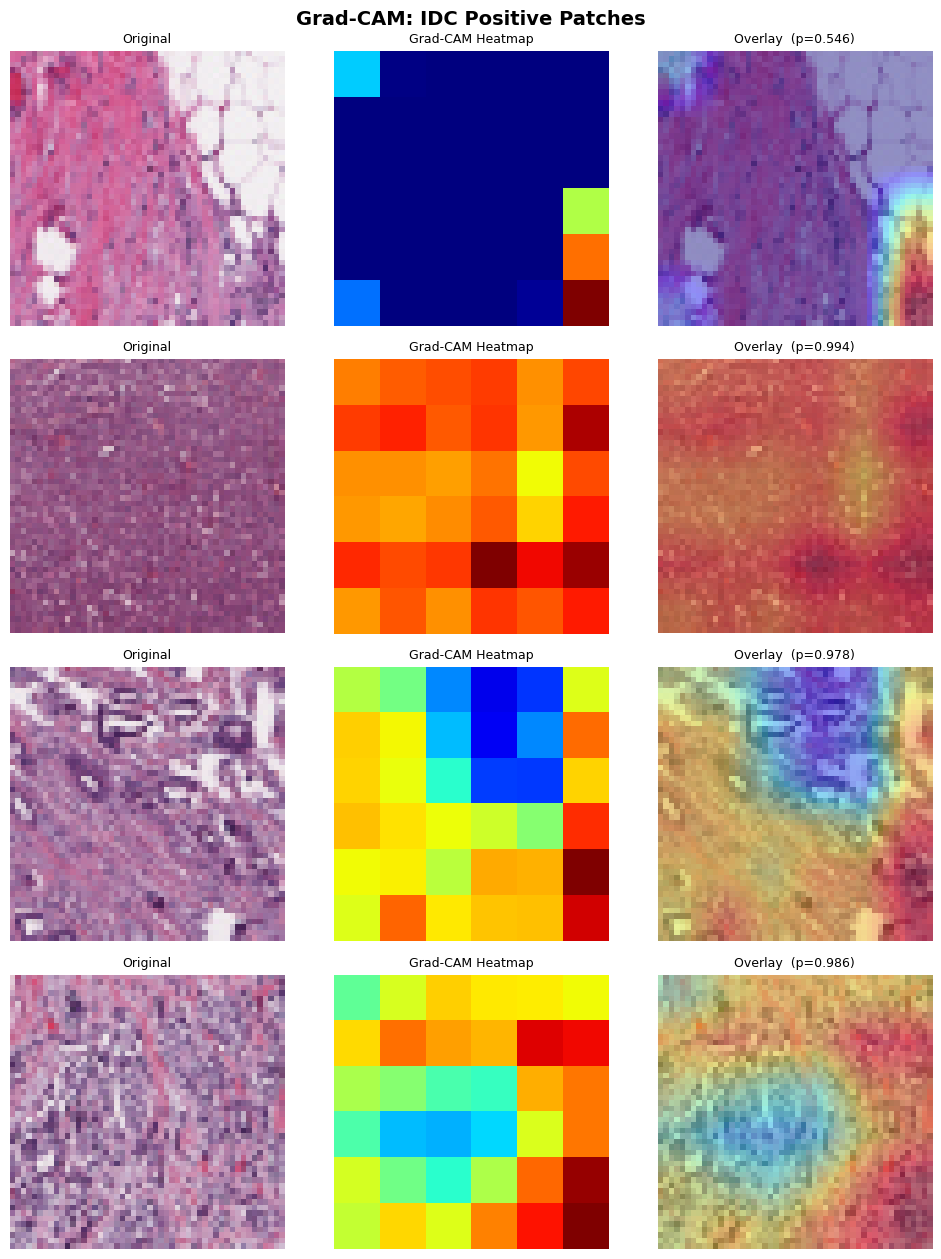

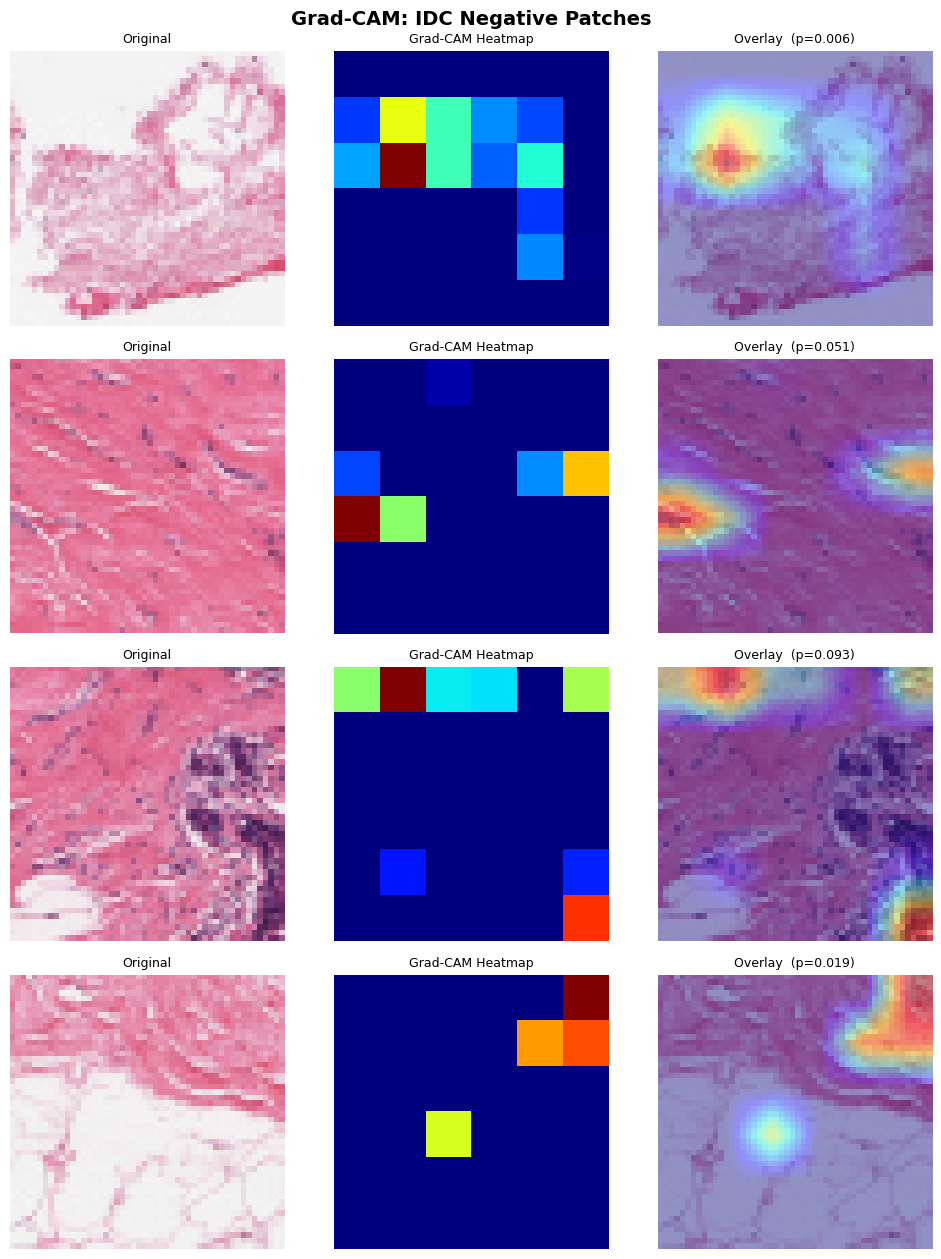

In [23]:
# Grad-CAM Generation and Visualisation
class GradCAM:
    def __init__(self, model, layer_name):
        self.model = model
        self.grad_model = keras.Model(
            inputs=model.inputs,
            outputs=[model.get_layer(layer_name).output, model.output]
        )

    def compute(self, img_array):
        """img_array: shape (1, H, W, C), float32 in [0,1]"""
        with tf.GradientTape() as tape:
            conv_out, predictions = self.grad_model(img_array, training=False)
            loss = predictions[:, 0]  # Probability of IDC+   # *** note: always explains the IDC+ score, so for negative patches the map shows regions pushing towards IDC+. The Streamlit app uses relu4b; this notebook uses conv4b.
        grads = tape.gradient(loss, conv_out)               # (1, H, W, C)
        pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))  # (C,) — importance weights
        conv_out = conv_out[0]                              # (H, W, C)
        heatmap = conv_out @ pooled_grads[..., tf.newaxis]  # (H, W, 1)
        heatmap = tf.squeeze(heatmap)
        heatmap = tf.nn.relu(heatmap)                       # Keep only positive activations
        heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8) # Normalise [0,1]
        return heatmap.numpy()

    def overlay(self, original_img, heatmap, alpha=0.4):
        heatmap_resized = tf.image.resize(heatmap[..., np.newaxis],
                                          [original_img.shape[0], original_img.shape[1]]).numpy()
        heatmap_resized = np.squeeze(heatmap_resized)
        heatmap_color = plt.cm.jet(heatmap_resized)[:, :, :3]  # RGB from colormap
        overlay = (1 - alpha) * original_img + alpha * heatmap_color
        return np.clip(overlay, 0, 1)


gradcam = GradCAM(best_model, layer_name='conv4b')
test_prob_by_path = dict(zip(test_paths, y_prob))   # *** NEW: lets the grid below sample only correctly classified patches


# Show Grad-CAM
def show_gradcam_grid(paths_list, true_class, n=4):
    """Display original + Grad-CAM overlay for n samples of given true class"""
    fig, axes = plt.subplots(n, 3, figsize=(10, n*3.2))
    class_label = 'IDC Positive' if true_class == 1 else 'IDC Negative'
    plt.suptitle(f'Grad-CAM: {class_label} Patches', fontsize=14, fontweight='bold')

    # *** CHANGED: sample only patches classified correctly at 0.5 (the section comment says 'correct predictions')
    correct = [p for p in paths_list if (test_prob_by_path[p] >= 0.5) == bool(true_class)]
    sampled = random.sample(correct, n)
    for row, path in enumerate(sampled):
        img = load_patch(path)   # *** was plt.load_patch (not a real function: AttributeError)
        img_tensor = img[np.newaxis, ...]  # (1, 50, 50, 3)
        heatmap = gradcam.compute(img_tensor)
        overlay = gradcam.overlay(img, heatmap)
        prob = float(best_model.predict(img_tensor, verbose=0)[0, 0])
        
        axes[row, 0].imshow(img)
        axes[row, 0].set_title('Original', fontsize=9)
        axes[row, 0].axis('off')
        
        axes[row, 1].imshow(heatmap, cmap='jet', vmin=0, vmax=1)
        axes[row, 1].set_title('Grad-CAM Heatmap', fontsize=9)
        axes[row, 1].axis('off')
        
        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(f'Overlay  (p={prob:.3f})', fontsize=9)
        axes[row, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig(f'gradcam_class{true_class}.png', dpi=150, bbox_inches='tight')
    plt.show()

show_gradcam_grid([p for p,l in zip(test_paths, test_labels) if l==1], true_class=1, n=4)
show_gradcam_grid([p for p,l in zip(test_paths, test_labels) if l==0], true_class=0, n=4)

False Negatives (missed cancers): 632
False Positives (false alarms)  : 4,706


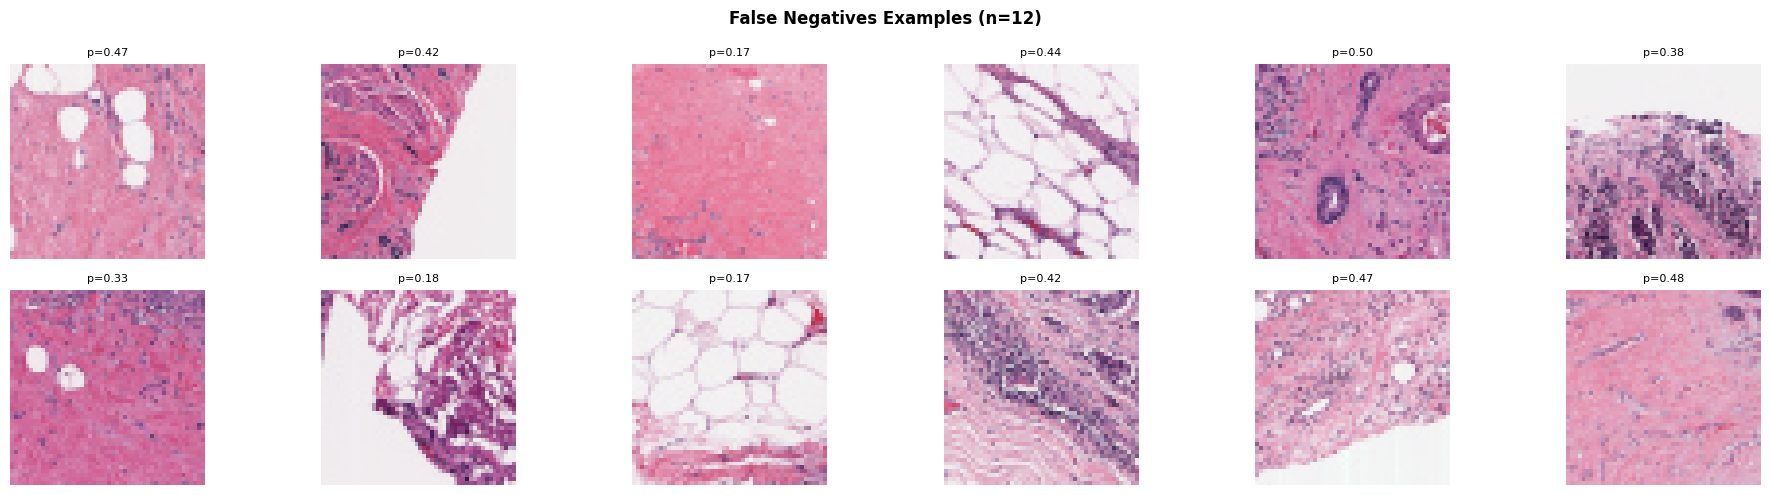

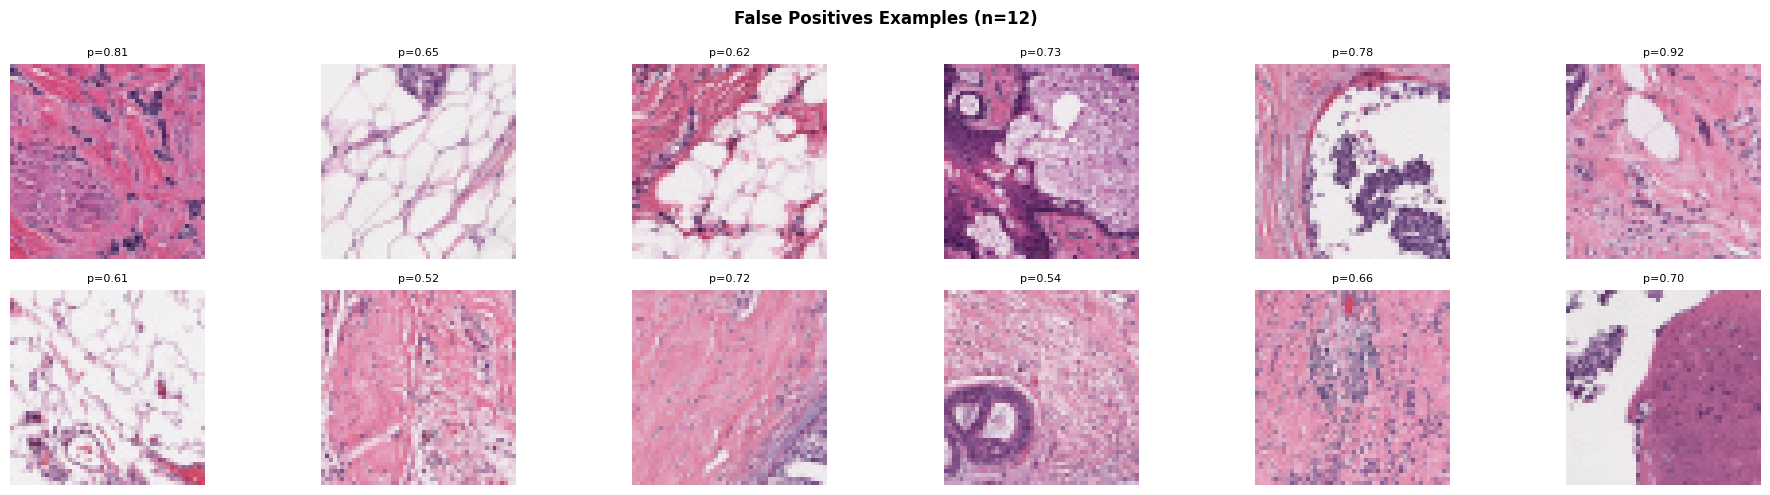

In [24]:
# False Negative Analysis

fn_indices = np.where((y_true == 1) & (y_pred == 0))[0]
fp_indices = np.where((y_true == 0) & (y_pred == 1))[0]
print(f'False Negatives (missed cancers): {len(fn_indices):,}')
print(f'False Positives (false alarms)  : {len(fp_indices):,}')

def show_errors(indices, label, n=12):
    sample = random.sample(list(indices), min(n, len(indices)))
    fig, axes = plt.subplots(2, n//2, figsize=(n*1.6, 5))
    axes = axes.flatten()
    for i, idx in enumerate(sample):
        img = plt.imread(test_paths[idx])
        axes[i].imshow(img)
        axes[i].set_title(f'p={y_prob[idx]:.2f}', fontsize=8)
        axes[i].axis('off')
    plt.suptitle(f'{label} Examples (n={len(sample)})', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'{label.lower().replace(" ","_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

show_errors(fn_indices, 'False Negatives', n=12)
show_errors(fp_indices, 'False Positives', n=12)

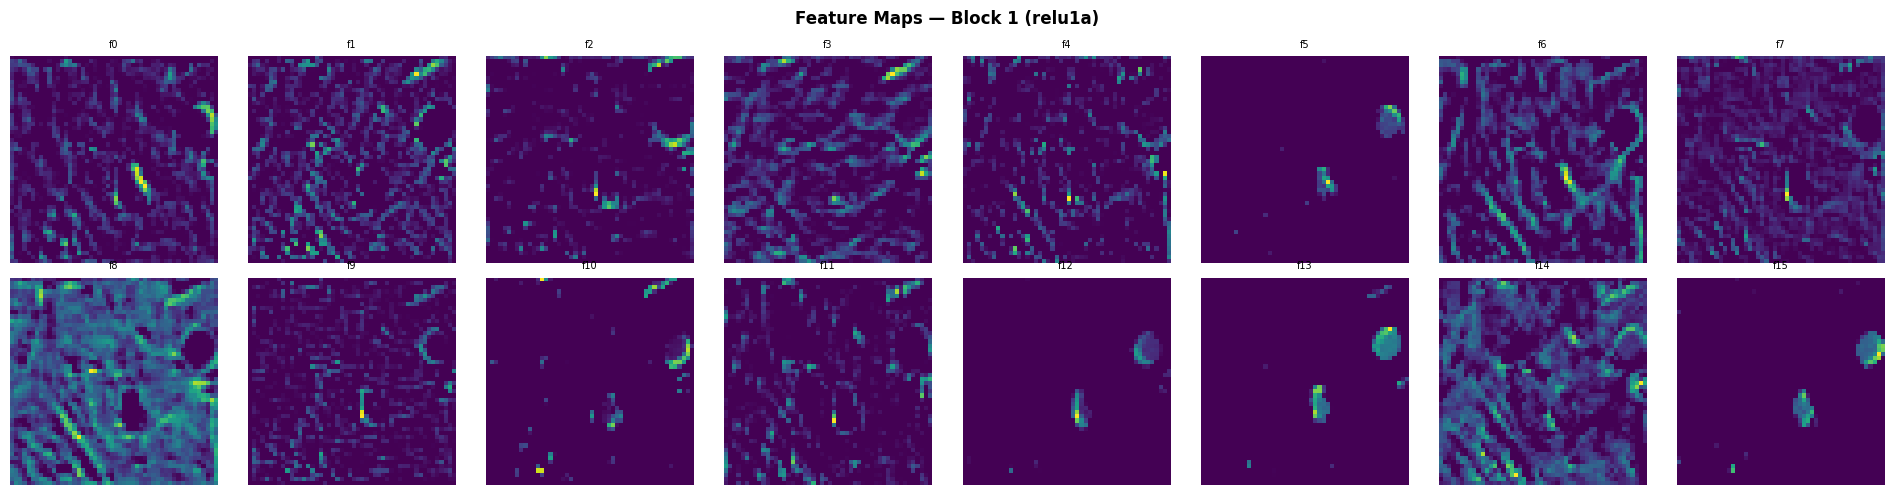

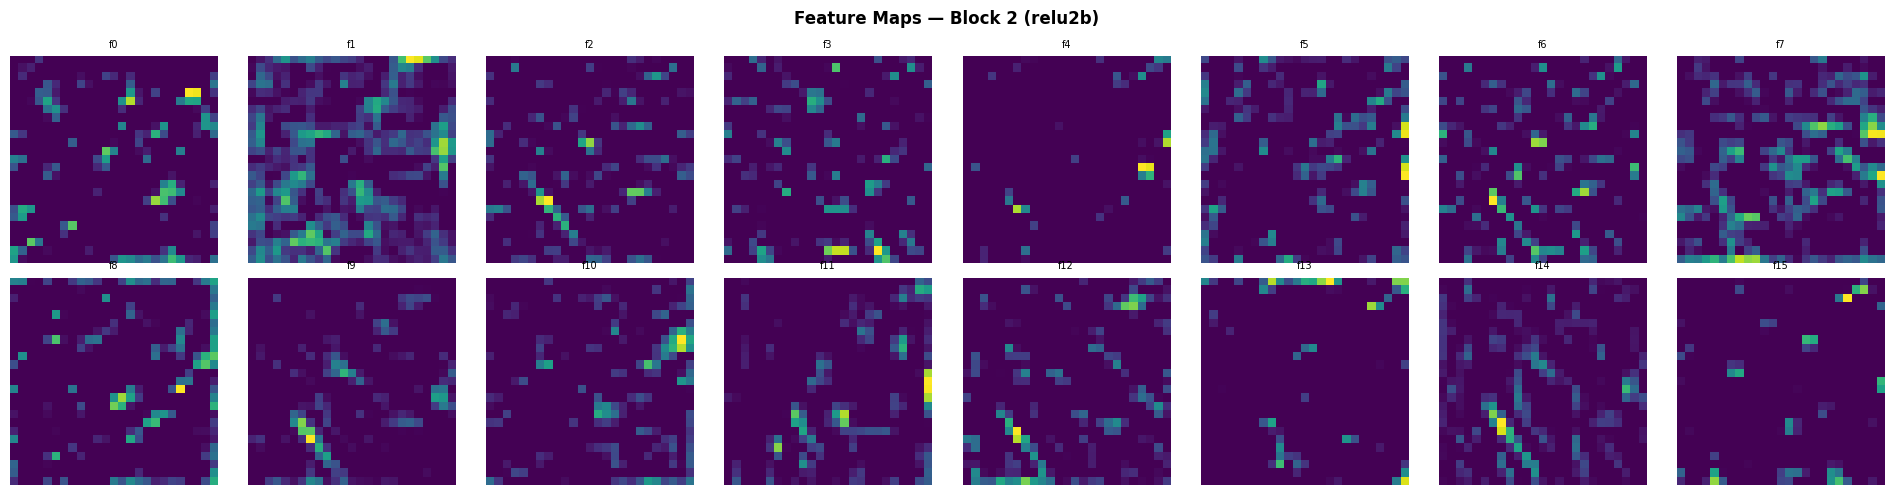

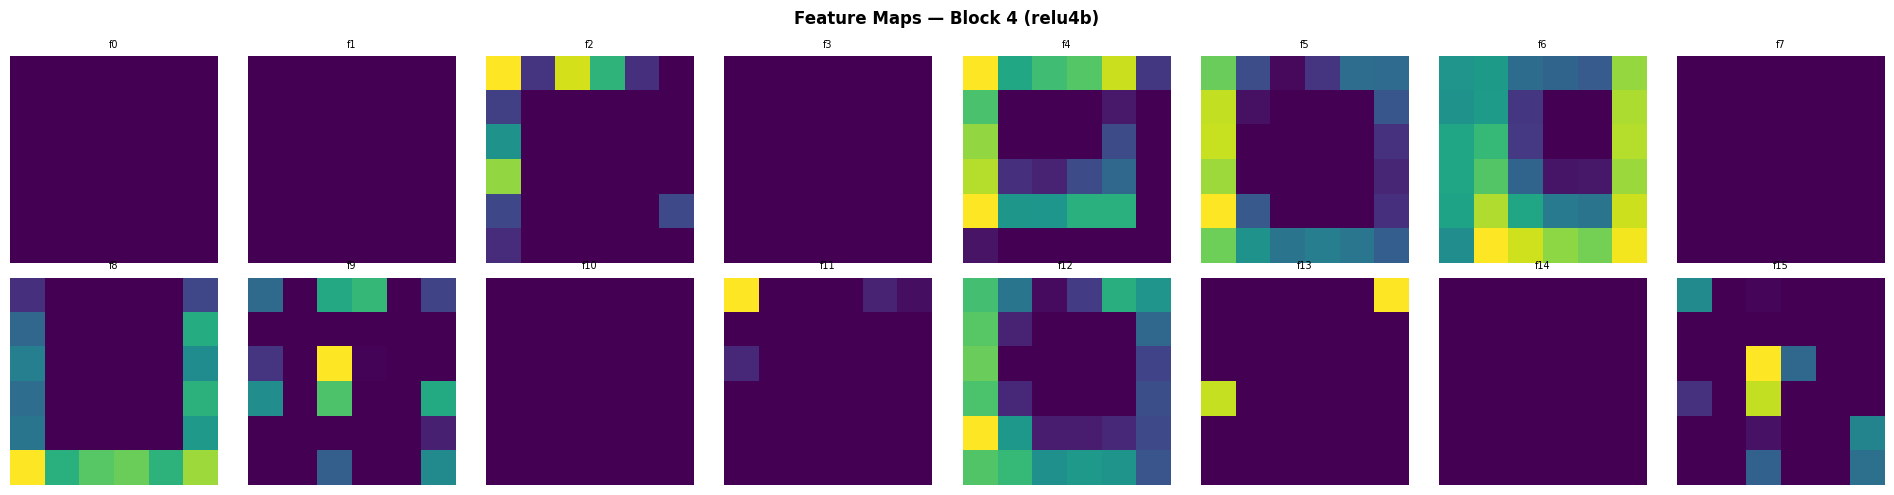

In [25]:
# Feature Maps
# Inspect what Block 1 and Block 4 have learned

activation_model = keras.Model(
    inputs=best_model.input,
    outputs=[
        best_model.get_layer('relu1a').output,   # Early features
        best_model.get_layer('relu2b').output,   # Mid-level
        best_model.get_layer('relu4b').output,   # High-level semantic
    ]
)

sample_img = load_patch(str(random.choice(pos_paths)))
acts = activation_model.predict(sample_img[np.newaxis, ...], verbose=0)

for block_idx, (act, title) in enumerate(zip(acts, ['Block 1 (relu1a)', 'Block 2 (relu2b)', 'Block 4 (relu4b)'])):
    n_filters = min(act.shape[-1], 16)
    fig, axes = plt.subplots(2, n_filters//2, figsize=(n_filters*1.2, 5))
    axes = axes.flatten()
    for i in range(n_filters):
        axes[i].imshow(act[0, :, :, i], cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f'f{i}', fontsize=7)
    plt.suptitle(f'Feature Maps — {title}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'feature_maps_block{block_idx+1}.png', dpi=150, bbox_inches='tight')
    plt.show()

## 10. Saving & Export <a id='10'></a>

In [26]:
# Multiple format save

os.makedirs('models', exist_ok=True)

# Keras native (preserves full model and optimiser state)
best_model.save('models/idc_cnn_finalV2.keras')
print('Saved: idc_cnn_finalV2.keras')

# SavedModel format (for TF Serving / deployment)
best_model.export('models/idc_cnn_savedmodel')
print('Saved: idc_cnn_savedmodel/')

# Final Summary
print('\n' + '='*60)
print('FINAL MODEL SUMMARY')
print('='*60)
print(f'Architecture     : 4-block CNN + GAP + Dense head')
print(f'Parameters       : {best_model.count_params():,}')
print(f'Input shape      : (50, 50, 3)')
print(f'Output           : Sigmoid probability of IDC+')
print(f'Test AUC-ROC     : {roc_auc_val:.4f}')
print(f'Test AUC-PR      : {pr_auc_score:.4f}')
print(f'Optimal threshold: {best_threshold:.4f} (Youden J)')
print('='*60)

Saved: idc_cnn_finalV2.keras
INFO:tensorflow:Assets written to: models/idc_cnn_savedmodel/assets


INFO:tensorflow:Assets written to: models/idc_cnn_savedmodel/assets


Saved artifact at 'models/idc_cnn_savedmodel'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 50, 50, 3), dtype=tf.float32, name='input_patch')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  137198036588448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137198036159120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137198036794032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137198036781008: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137198036786992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137198035231920: TensorSpec(shape=(1, 1, 3), dtype=tf.float32, name=None)
  137198035232096: TensorSpec(shape=(1, 1, 3), dtype=tf.float32, name=None)
  137198036670016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137198036667728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137198036673008: TensorSpec(shape=(), dtype=tf.resource, name=None

In [27]:
try:
    import keras.src.backend as keras_backend

    def find_seed_generators(obj, seen=None):
        if seen is None:
            seen = set()
        if id(obj) in seen:
            return []
        seen.add(id(obj))
        found = []
        if hasattr(obj, "_seed_generators"):
            found.extend(obj._seed_generators)
        for attr_name in ("_layers",):
            if hasattr(obj, attr_name):
                for item in getattr(obj, attr_name):
                    found.extend(find_seed_generators(item, seen))
        if hasattr(obj, "_outbound_nodes"):
            for node in obj._outbound_nodes:
                if hasattr(node, "operation"):
                    found.extend(find_seed_generators(node.operation, seen))
        return found

    generators = find_seed_generators(best_model)
    print(f"Found {len(generators)} seed generators")

    for g in generators:
        g.backend = None

    try:
        best_model.save('models/idc_cnn_finalV2.h5', include_optimizer=False)
        print("Saved: idc_cnn_finalV2.h5")
    finally:
        for g in generators:
            g.backend = keras_backend
except Exception as e:
    print(f".h5 export skipped: {e}")


Found 10 seed generators
Saved: idc_cnn_finalV2.h5
